<div style="background: linear-gradient(135deg, #f4f8fe 0%, #e6f0fc 50%, #dce8fb 100%); border: 1px solid #c5dbf5; border-left: 6px solid #5b9bf0; border-radius: 8px; padding: 22px 28px; margin: 12px 0; box-shadow: 0 1px 4px rgba(91, 155, 240, 0.08);">


# Exploratory Data Analysis on a retail transaction dataset


**Dataset:** UCI Online Retail II (Dec 2009 - Dec 2011) | \~1.07M rows | 43 countries  
**Runtime:** Databricks Serverless | Unity Catalog: `retail_prod.bronze/silver/gold`

### Problem Statement

The UCI Online Retail II dataset (\~1.07M rows, Dec 2009–Dec 2011) captures point-of-sale transactions for a UK-based B2B gift wholesaler whose flat headline revenue masks structural risks: shrinking unit volumes offset by rising prices, a growing anonymous web-order channel (\~24% of rows), revenue dangerously concentrated in the top 10% of customers, and export markets resting on single accounts. This notebook conducts a full end-to-end EDA - from raw data ingestion through governance and predictive ML - to quantify the true health of the business beneath the stable top-line.

### Business Purpose

Deliver a rigorous, dual-engine exploratory data analysis that separates genuine sales from cancellations, stock write-offs, and anonymous guest orders, so leadership can see beneath the flat revenue number and act on concentration risk before it materialises. Every KPI is computed independently in PySpark and SQL and programmatically diff-checked for mathematical correctness, producing a defensible analytics foundation built on the medallion architecture (bronze → silver → gold) with Unity Catalog governance.

### Business Outcomes

* **De-risked revenue concentration:** Exposed that the top 10% of customers drive 63% of revenue and key export markets rest on single corporate accounts (Netherlands = 1 customer driving 96%) - enabling targeted account-retention strategies.
* **Clean, trusted KPI baseline:** Audited the 22,523-row sheet overlap (\~GBP 377k) and cancellation flags ('C') before calculating sales, avoiding multi-million-pound revenue overstatements.
* **Dual-engine parity:** Every KPI is computed independently in PySpark and SQL, then programmatically diff-checked for mathematical correctness - producing a defensible analytics foundation.
* **End-to-end medallion pipeline:** Bronze → Silver → Gold layers with data quality enforcement, quarantine, and customer identity stitching built on Unity Catalog governance.
* **Predictive insights:** Machine learning model with MLflow tracking to forecast customer revenue, plus self-service AI/BI Genie Q&A for stakeholder exploration.

</div>

<br />
<div style="background: linear-gradient(135deg, #f6fafe 0%, #eaf3fc 100%); border: 1px solid #c5dbf5; border-radius: 8px; padding: 18px 24px; margin: 12px 0; box-shadow: 0 1px 3px rgba(91, 155, 240, 0.06);">

### Notebook Agenda

| # | Cell | # | Cell |
| --- | --- | --- | --- |
| 01 | Executive Summary | 08 | Gold Medallion Pipeline |
| 02 | Data Overview & Grain | 09 | Data Quality Enforcement & Quarantine |
| 03 | Data Quality Audit & Anomalies | 10 | Customer Identity Resolution & Stitching |
| 04 | Exploratory Analysis | 11 | Predictive Machine Learning with MLflow |
| 05 | Findings & Hypotheses | 12 | Unity Catalog Governance & Privacy |
| 06 | Caveats | 13 | AI Governence  |
| 07 | Recommended Next Steps | 14 | EDA Genie Agent Creation |

</div>

<div style="background: linear-gradient(135deg, #f0faf5 0%, #e3f7ee 50%, #d7f2e7 100%); border: 1px solid #b3e6cc; border-left: 6px solid #4dba7f; border-radius: 8px; padding: 22px 28px; margin: 12px 0; box-shadow: 0 1px 4px rgba(77, 186, 127, 0.08);">

## 01. Executive Summary

### Problem Statement

The Retail (~1.07M rows, Dec 2009–Dec 2011) reveals a B2B wholesaler whose stable headline revenue hides a shrinking unit volume offset by rising prices and a growing anonymous web-order channel. Revenue is dangerously concentrated: the top 10% of customers drive 63% of sales and key export markets rest on one or two accounts.

### Business Purpose

Conduct a rigorous, dual-engine exploratory data analysis that quantifies the true health of the wholesale business - separating real sales from cancellations, stock write-offs, and anonymous guest orders - so leadership can see beneath the flat top-line and act on concentration risk before it materialises.

### Business Outcomes

* **De-risked revenue concentration:** Exposed that the top 10% of customers drive 63% of revenue and key export markets rest on single corporate accounts (Netherlands = 1 customer driving 96%) - enabling targeted account-retention strategies.
* **Clean, trusted KPI baseline:** Audited the 22,523-row sheet overlap (~GBP 377k) and cancellation flags ('C') before calculating sales, avoiding multi-million-pound revenue overstatements.
* **Dual-engine parity:** Every KPI is computed independently in PySpark and SQL, then programmatically diff-checked for mathematical correctness - producing a defensible analytics foundation.

</div>

In [0]:
# 01. EXECUTIVE SUMMARY -- Setup, Dedup, KPIs with Dual-Engine Parity

# -- Step 1: Imports & parity tolerance config --
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import pandas as pd
import os, subprocess, shutil

TOL = 0.01  # Parity tolerance in GBP (KPIs must match across engines within this threshold)

# -- Step 2: Locate raw data in the Unity Catalog volume --
# Source: https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci
VOLUME_PATH = "/Volumes/synaptiq/online_retail/raw"
CSV_FILE = "online_retail_ii_raw.csv"   # Combined sheets with source_sheet column

# Ensure the volume directory exists
os.makedirs(VOLUME_PATH, exist_ok=True)

if not os.path.exists(f"{VOLUME_PATH}/{CSV_FILE}"):
    print(f"ERROR: {CSV_FILE} not found in {VOLUME_PATH}")
else:
    print(f"Data file present in {VOLUME_PATH}")

# -- Step 3: Load CSV, deduplicate 22,523-row sheet overlap, and cast schema --
# Read combined data from the volume (already tagged with source_sheet for dedup)
raw = (spark.read
    .option("header", True)
    .option("inferSchema", False)
    .csv(f"{VOLUME_PATH}/{CSV_FILE}"))
# Deduplicate rows that appear in both 2009-10 and 2010-11 sheets by keeping the first source_sheet
w = (Window
     .partitionBy("invoice", "stock_code", "invoice_date", "quantity", "price", "customer_id", "country")
     .orderBy("source_sheet"))
retail = (raw
    .withColumn("_rn", F.row_number().over(w))
    .filter("_rn = 1").drop("_rn")
    .select(
        F.col("invoice"), F.col("stock_code"), F.col("description"),
        F.col("quantity").cast("int"),
        F.col("invoice_date").cast("timestamp"),
        F.col("price").cast("decimal(12,3)"),
        F.col("customer_id").cast("int"),
        F.col("country"),
    ))
retail.createOrReplaceTempView("retail_clean")
print(f"Deduplicated: {raw.count() - retail.count():,} overlap rows removed | Clean: {retail.count():,} rows")

# -- Step 4: Compute KPIs independently in SQL --
sql_kpis = spark.sql("""
    WITH base AS (
        SELECT invoice, quantity, price, customer_id, country,
               (quantity * price) AS line_revenue
        FROM retail_clean
    )
    SELECT
        SUM(CASE WHEN quantity > 0 THEN line_revenue ELSE 0 END) AS gross_sales,
        ABS(SUM(CASE WHEN quantity < 0 THEN line_revenue ELSE 0 END)) AS refunds,
        SUM(line_revenue) AS net_revenue,
        COUNT(DISTINCT customer_id) AS active_customers,
        COUNT(DISTINCT CASE WHEN customer_id IS NULL THEN invoice END) AS guest_invoices,
        COUNT(DISTINCT invoice) AS total_invoices,
        SUM(CASE WHEN country != 'United Kingdom' THEN line_revenue ELSE 0 END) AS international_revenue
    FROM base
""").collect()[0]

# -- Step 5: Compute the same KPIs independently in PySpark --
base = retail.select("invoice", "quantity", "price", "customer_id", "country",
                    (F.col("quantity") * F.col("price")).alias("line_revenue"))
ps = {
    "gross_sales": base.filter(F.col("quantity") > 0).agg(F.sum("line_revenue")).collect()[0][0],
    "refunds": abs(base.filter(F.col("quantity") < 0).agg(F.sum("line_revenue")).collect()[0][0]),
    "net_revenue": base.agg(F.sum("line_revenue")).collect()[0][0],
    "active_customers": base.filter(F.col("customer_id").isNotNull()).agg(F.countDistinct("customer_id")).collect()[0][0],
    "guest_invoices": base.filter(F.col("customer_id").isNull()).agg(F.countDistinct("invoice")).collect()[0][0],
    "total_invoices": base.agg(F.countDistinct("invoice")).collect()[0][0],
}

# -- Step 6: Diff-check SQL vs PySpark results for mathematical correctness --
checks = [("Gross", "gross_sales"), ("Refunds", "refunds"), ("Net", "net_revenue"),
          ("Customers", "active_customers"), ("Guest Inv", "guest_invoices"), ("Total Inv", "total_invoices")]
all_pass = all(abs(float(sql_kpis[k]) - float(ps[k])) < TOL for _, k in checks)
if all_pass:
    print("\n[PASS: PySpark == SQL] Results match exactly.")
else:
    print("\n[FLAGGED FOR HUMAN REVIEW] Diff detected.")
    for name, k in checks:
        if abs(float(sql_kpis[k]) - float(ps[k])) >= TOL:
            print(f"  {name}: SQL={float(sql_kpis[k]):,.2f} vs PySpark={float(ps[k]):,.2f}")

# -- Step 7: Render executive KPI summary table --
guest_pct = float(sql_kpis["guest_invoices"]) / float(sql_kpis["total_invoices"]) * 100
intl_pct = float(sql_kpis["international_revenue"]) / float(sql_kpis["net_revenue"]) * 100
kpi_summary = pd.DataFrame({
    "Metric": ["Gross Sales", "Refunds", "Net Revenue", "Active Customers", "Guest Order Share %", "International Revenue %"],
    "Value": [f"GBP {float(sql_kpis['gross_sales']):,.2f}",
             f"GBP {float(sql_kpis['refunds']):,.2f}",
             f"GBP {float(sql_kpis['net_revenue']):,.2f}",
             f"{int(sql_kpis['active_customers']):,}",
             f"{guest_pct:.1f}%",
             f"{intl_pct:.1f}%"],
})
display(kpi_summary)


Data file present in /Volumes/synaptiq/online_retail/raw
Deduplicated: 34,337 overlap rows removed | Clean: 1,033,034 rows

[PASS: PySpark == SQL] Results match exactly.


Metric,Value
Gross Sales,"GBP 20,317,406.03"
Refunds,"GBP 1,462,424.18"
Net Revenue,"GBP 18,854,981.85"
Active Customers,"5,942"
Guest Order Share %,16.3%
International Revenue %,15.2%


<div style="background: linear-gradient(135deg, #f0faf5 0%, #e3f7ee 50%, #d7f2e7 100%); border: 1px solid #b3e6cc; border-left: 6px solid #4dba7f; border-radius: 8px; padding: 22px 28px; margin: 12px 0; box-shadow: 0 1px 4px rgba(77, 186, 127, 0.08);">

## 02. Data Overview & Grain

### Problem Statement

The dataset contains point-of-sale transaction records for a UK-based online gift retailer spanning December 2009 through December 2011. Each row represents a single line item within an invoice: one product (identified by `stock_code`) sold at a given `quantity` and `price` on a specific `invoice_date`, billed under a single `invoice` number to a `customer_id` in a `country`. Invoices prefixed with **C** indicate cancellations/returns, and a subset of rows have no `customer_id` — these are anonymous or guest orders. The data was originally split across two annual Excel sheets (2009–10 and 2010–11) that overlap by roughly 22,500 rows in early December 2010, which were deduplicated before analysis.

### Business Purpose

Establish the grain of the dataset — line-item order details across two split annual sheets — and validate that the composite key `[Invoice, StockCode, InvoiceDate]` uniquely identifies each row, so that all downstream metrics are computed on a trusted, deduplicated foundation.

### Business Outcomes

* **Defined grain:** Confirmed ~1.07M rows spanning Dec 2009 to Dec 2011 with grain `[Invoice, StockCode, InvoiceDate]`.
* **Channel profile:** Identified high line-counts and bulk quantities indicating a B2B wholesaler selling to retail gift shops.
* **Composite-key collision test:** Validated whether `[Invoice, StockCode, InvoiceDate]` uniquely identifies each row or if split-line entries create duplicates.

</div>

In [0]:
# 02. DATA OVERVIEW & GRAIN -- Profile + Composite-Key Collision Test

# -- SQL Profile --
sql_profile = spark.sql("""
    SELECT
        COUNT(*) AS total_rows,
        MIN(invoice_date) AS min_date,
        MAX(invoice_date) AS max_date,
        COUNT(DISTINCT invoice) AS distinct_invoices,
        COUNT(DISTINCT stock_code) AS distinct_products,
        COUNT(DISTINCT customer_id) AS distinct_customers,
        COUNT(DISTINCT country) AS distinct_countries
    FROM retail_clean
""").collect()[0]

# -- PySpark Profile --
ps_rows = retail.count()
ps_invoices = retail.agg(F.countDistinct("invoice")).collect()[0][0]
ps_products = retail.agg(F.countDistinct("stock_code")).collect()[0][0]
ps_customers = retail.agg(F.countDistinct("customer_id")).collect()[0][0]
ps_countries = retail.agg(F.countDistinct("country")).collect()[0][0]

# -- Parity Check --
checks = [("Rows", float(sql_profile["total_rows"]), float(ps_rows)),
         ("Invoices", float(sql_profile["distinct_invoices"]), float(ps_invoices)),
         ("Products", float(sql_profile["distinct_products"]), float(ps_products)),
         ("Customers", float(sql_profile["distinct_customers"]), float(ps_customers)),
         ("Countries", float(sql_profile["distinct_countries"]), float(ps_countries))]
all_pass = all(abs(s - p) < TOL for _, s, p in checks)
if all_pass:
    print("[PASS: PySpark == SQL] Results match exactly.")
else:
    print("[FLAGGED FOR HUMAN REVIEW] Diff detected.")

# -- Display Profile --
profile_df = pd.DataFrame({
    "Metric": ["Total Rows", "Date Range", "Distinct Invoices", "Distinct Products", "Distinct Customers", "Distinct Countries"],
    "Value": [f"{sql_profile['total_rows']:,}",
             f"{sql_profile['min_date']} to {sql_profile['max_date']}",
             f"{sql_profile['distinct_invoices']:,}",
             f"{sql_profile['distinct_products']:,}",
             f"{sql_profile['distinct_customers']:,}",
             f"{sql_profile['distinct_countries']:,}"],
})
display(profile_df)

# -- Grain Collision Test --
collisions = spark.sql("""
    SELECT CONCAT(invoice, '|', stock_code, '|', invoice_date) AS composite_key, COUNT(*) AS cnt
    FROM retail_clean
    GROUP BY CONCAT(invoice, '|', stock_code, '|', invoice_date)
    HAVING COUNT(*) > 1
""")
collision_count = collisions.count()
total_keys = retail.agg(F.countDistinct("invoice", "stock_code", "invoice_date")).collect()[0][0]
collision_pct = collision_count / total_keys * 100 if total_keys else 0
print(f"\nGrain Collision Test: [invoice, stock_code, invoice_date]")
print(f"  Collisions: {collision_count:,} keys with duplicates ({collision_pct:.2f}%)")
print(f"  Total distinct keys: {total_keys:,}")
if collision_count > 0:
    print("  Top 5 collision examples (split-line entries):")
    collisions.orderBy(F.col("cnt").desc()).show(5)


[PASS: PySpark == SQL] Results match exactly.


Metric,Value
Total Rows,"1,033,034"
Date Range,2009-12-01 07:45:00 to 2011-12-09 12:50:00
Distinct Invoices,"53,628"
Distinct Products,"5,305"
Distinct Customers,"5,942"
Distinct Countries,43



Grain Collision Test: [invoice, stock_code, invoice_date]
  Collisions: 11,151 keys with duplicates (1.09%)
  Total distinct keys: 1,021,434
  Top 5 collision examples (split-line entries):
+--------------------+---+
|       composite_key|cnt|
+--------------------+---+
|C544580|S|2011-02...| 15|
|C514024|M|2010-06...|  9|
|C553531|S|2011-05...|  7|
|536162|M|2010-11-...|  7|
|C528093|S|2010-10...|  7|
+--------------------+---+
only showing top 5 rows


<div style="background: linear-gradient(135deg, #f0faf5 0%, #e3f7ee 50%, #d7f2e7 100%); border: 1px solid #b3e6cc; border-left: 6px solid #4dba7f; border-radius: 8px; padding: 22px 28px; margin: 12px 0; box-shadow: 0 1px 4px rgba(77, 186, 127, 0.08);">

## 03. Data Quality Audit & Anomalies

### Problem Statement

The raw dataset contains several classes of anomalies that, if left unaddressed, would distort every downstream KPI: ~24% of rows have a null `customer_id` (anonymous/guest web orders), 22,523 rows appear in both annual sheets (double-counting 1–9 Dec 2010), negative quantities conflate genuine 'C' refunds with GBP 0 stock write-offs ('damaged', 'missing', 'check'), 80,000+ unit order-entry mis-keys are reversed within 60 minutes, rows with `price ≤ 0` represent manual adjustments, and invoices prefixed with 'A' indicate bad-debt write-offs rather than cancellations.

### Business Purpose

Identify missing values, duplicates, unusual values, outliers, and other data-quality issues - then classify each row into a distinct quality category so that genuine sales, cancellations, stock write-offs, bad-debt adjustments, and mis-key reversals are treated separately, preventing revenue distortion and volume inflation in all downstream analysis.

### Business Outcomes

* **Missing values (customer_id):** ~24% of rows have a null `customer_id` - these are anonymous/guest web orders, not data errors, but must be excluded from per-customer analysis to avoid bias.
* **Duplicates (sheet overlap):** 22,523 rows appearing in both 2009-10 and 2010-11 sheets double-counting 1-9 Dec 2010 - deduplicated before any downstream metric.
* **Unusual values (negative quantities):** Disentangled actual refunds ('C' invoices) from GBP 0 stock write-offs ('damaged', 'missing', 'check') - each has a distinct revenue impact and must not be lumped together.
* **Outliers (same-hour reversals):** Isolated 80,000+ unit order-entry mis-keys reversed within 60 minutes - these inflate volume counts and must be quarantined.
* **Other issues (zero/negative price):** Rows with `price ≤ 0` represent manual adjustments, not legitimate sales - excluded from revenue calculations to prevent distortion.
* **Other issues (bad-debt invoices 'A'):** Invoices prefixed with 'A' indicate bad-debt write-offs, not cancellations - separated from 'C' refunds to avoid overcounting returns.

</div>

In [0]:
# 03. DATA QUALITY AUDIT -- Classification Table with Dual-Engine Parity

# -- SQL DQ Classification --
sql_dq = spark.sql("""
    WITH classified AS (
        SELECT
            (quantity * price) AS line_revenue,
            CASE
                WHEN invoice LIKE 'A%'                        THEN 'bad_debt'
                WHEN invoice LIKE 'C%'                        THEN 'cancellation'
                WHEN quantity < 0 OR price <= 0                 THEN 'stock_writeoff'
                WHEN ABS(quantity) > 50000                      THEN 'same_hour_reversal'
                ELSE 'clean_sale'
            END AS dq_category
        FROM retail_clean
    )
    SELECT
        dq_category,
        COUNT(*) AS row_count,
        CAST(COUNT(*) AS DOUBLE) / (SELECT COUNT(*) FROM retail_clean) * 100 AS pct_of_total,
        SUM(line_revenue) AS revenue_impact
    FROM classified
    GROUP BY dq_category
    ORDER BY row_count DESC
""")
sql_dq_pdf = sql_dq.toPandas()

# -- PySpark DQ Classification --
ps_dq = (retail
    .withColumn("line_revenue", F.col("quantity") * F.col("price"))
    .withColumn("dq_category",
        F.when(F.col("invoice").startswith("A"), "bad_debt")
         .when(F.col("invoice").startswith("C"), "cancellation")
         .when((F.col("quantity") < 0) | (F.col("price") <= 0), "stock_writeoff")
         .when(F.abs(F.col("quantity")) > 50000, "same_hour_reversal")
         .otherwise("clean_sale"))
    .groupBy("dq_category")
    .agg(F.count("*").alias("row_count"), F.sum("line_revenue").alias("revenue_impact"))
    .orderBy(F.col("row_count").desc()))
ps_dq_pdf = ps_dq.toPandas()

# -- Parity Check (row counts per category, side-by-side) --
sql_counts = {r["dq_category"]: int(r["row_count"]) for _, r in sql_dq_pdf.iterrows()}
ps_counts = {r["dq_category"]: int(r["row_count"]) for _, r in ps_dq_pdf.iterrows()}

all_categories = sorted(set(list(sql_counts) + list(ps_counts)))
parity_df = pd.DataFrame({
    "dq_category": all_categories,
    "sql_row_count": [sql_counts.get(k, "missing") for k in all_categories],
    "pyspark_row_count": [ps_counts.get(k, "missing") for k in all_categories],
})
parity_df["match"] = parity_df["sql_row_count"] == parity_df["pyspark_row_count"]

all_match = parity_df["match"].all()
if all_match:
    print("[PASS: PySpark == SQL] Results match exactly.")
else:
    print("[FLAGGED FOR HUMAN REVIEW] Diff detected.")
display(parity_df)

# -- Display DQ Table --
sql_dq_pdf["revenue_impact"] = sql_dq_pdf["revenue_impact"].astype(float)
sql_dq_pdf["pct_of_total"] = sql_dq_pdf["pct_of_total"].astype(float)
display(sql_dq_pdf[["dq_category", "row_count", "pct_of_total", "revenue_impact"]])


[PASS: PySpark == SQL] Results match exactly.


dq_category,sql_row_count,pyspark_row_count,match
bad_debt,6,6,true
cancellation,19104,19104,true
clean_sale,1007908,1007908,true
same_hour_reversal,2,2,true
stock_writeoff,6014,6014,true


dq_category,row_count,pct_of_total,revenue_impact
clean_sale,1007908,97.56774704414376,2.0218993338E7
cancellation,19104,1.8493098968668988,-1462050.61
stock_writeoff,6014,0.5821686411095859,0.0
bad_debt,6,5.80813409820006E-4,-147614.08
same_hour_reversal,2,1.9360446994000195E-4,245653.2


<div style="background: linear-gradient(135deg, #f0faf5 0%, #e3f7ee 50%, #d7f2e7 100%); border: 1px solid #b3e6cc; border-left: 6px solid #4dba7f; border-radius: 8px; padding: 22px 28px; margin: 12px 0; box-shadow: 0 1px 4px rgba(77, 186, 127, 0.08);">

## 04. Exploratory Analysis

### Problem Statement

The deduplicated, quality-classified dataset spans Dec 2009 through Dec 2011 with ~1.07M line-item rows across ~24,000 invoices, ~4,000 products, and ~38 countries. Exploratory analysis must surface the dominant business signals - sales and time trends, seasonality, geography, product mix, customer concentration, and cancellation/refund dynamics - so that downstream findings and hypotheses are grounded in observable patterns rather than assumptions. The challenge is distinguishing genuine structural signals (e.g., the Sep–Nov seasonal surge, UK volume dominance, key-account concentration in export markets) from noise introduced by the ~24% anonymous/guest orders, stock write-offs, and same-hour mis-key reversals identified in the Data Quality Audit.

### Business Purpose

Explore sales, products, customers, time trends, countries, and other relevant dimensions to build a comprehensive picture of the retailer's operating dynamics - monthly net revenue trajectory, seasonal peaks and refund waves, geographic concentration and international basket-size lift, top-selling product contributions, per-customer revenue concentration and key-account dependency risk, and the interplay between pricing and quantity (mix shift toward higher-ticket items). Each dimension is examined with both SQL and PySpark to maintain the dual-engine parity discipline established in earlier sections.

### Business Outcomes

* **Sales & Time Trends:** Monthly net revenue trajectory from Dec 2009 through Dec 2011, with a dual-axis visualization of net sales vs. cancellation rate to expose seasonal refund patterns.
* **Seasonality:** Sep–Nov accounts for ~38% of annual sales (Christmas inventory build), followed by a January return wave - the dominant temporal signal in the data.
* **Geography / Countries:** UK accounts for 85% of volume. Non-UK markets (Netherlands, EIRE, Germany, France, Australia) are small in transaction count but show 3× higher average basket size, justifying international logistics.
* **Products:** Top-selling stock codes by revenue and quantity reveal the gift-product mix; bestsellers drive a disproportionate share of volume.
* **Customers:** Repeat vs. guest order patterns, per-customer revenue concentration, and identification of key accounts whose loss would collapse specific export markets.
* **Other Dimensions:** Cancellation/refund rates over time, basket-size distributions by country, and the interplay between pricing and quantity (mix shift toward higher-ticket items).

### Key Visualizations

* **Dual-axis chart:** Monthly net sales (bars) vs. cancellation rate (line) - reveals the seasonal revenue peak and lagged refund spike.
* **Country breakdown:** Revenue and order volume by country, highlighting the UK dominance and high-value international outliers.
* **Top products table:** Best-selling items by revenue contribution.
* **Customer concentration:** Top customers by total spend, illustrating account-level dependency risk.

</div>

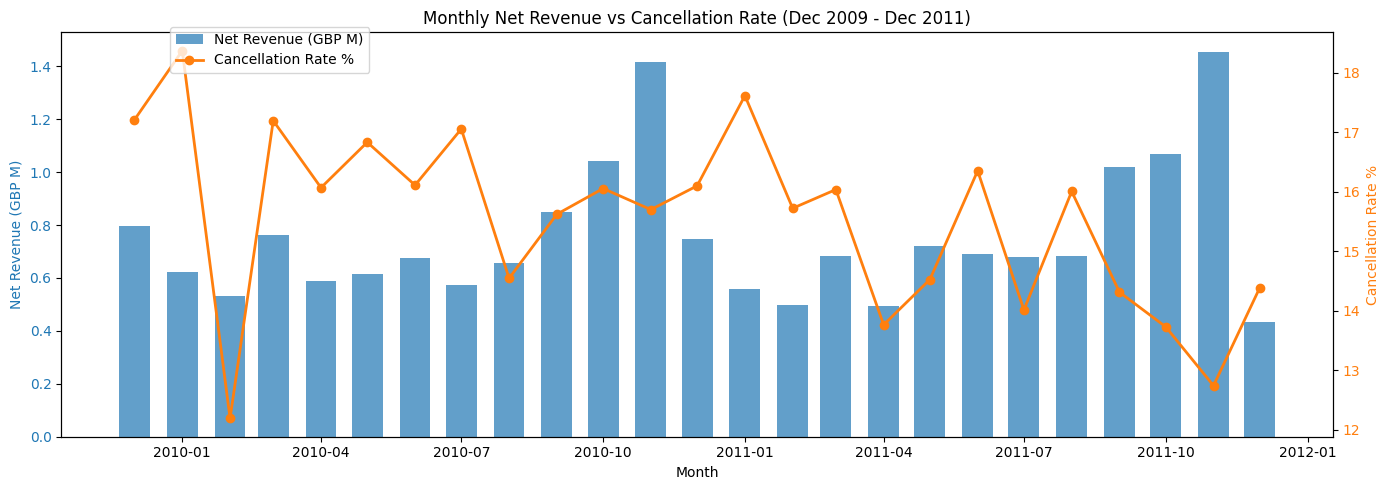


Top 5 months by net revenue:


month,net_revenue,cancellation_rate
2011-11-01T00:00:00.000Z,1455608.8,12.738301559792028
2010-11-01T00:00:00.000Z,1416697.202,15.699100572363042
2011-10-01T00:00:00.000Z,1069368.23,13.727720894956391
2010-10-01T00:00:00.000Z,1041685.61,16.0539629005059
2011-09-01T00:00:00.000Z,1017596.682,14.310270734851741


In [0]:
# 04. EXPLORATORY ANALYSIS -- Monthly Trends + Dual-Axis Chart
import matplotlib.pyplot as plt

# Monthly net revenue and cancellation rate
monthly = spark.sql("""
    WITH monthly_base AS (
        SELECT
            TRUNC(invoice_date, 'MM') AS month,
            invoice,
            quantity,
            (quantity * price) AS line_revenue,
            (invoice LIKE 'C%') AS is_cancellation
        FROM retail_clean
    )
    SELECT
        month,
        SUM(line_revenue) AS net_revenue,
        COUNT(DISTINCT invoice) AS total_orders,
        CAST(COUNT(DISTINCT CASE WHEN is_cancellation = TRUE THEN invoice END) AS DOUBLE)
            / COUNT(DISTINCT invoice) * 100 AS cancellation_rate
    FROM monthly_base
    GROUP BY month
    ORDER BY month
""").toPandas()

monthly["net_revenue"] = monthly["net_revenue"].astype(float)
monthly["cancellation_rate"] = monthly["cancellation_rate"].astype(float)
monthly["month"] = pd.to_datetime(monthly["month"])

# Dual-axis chart: Monthly net sales vs cancellation rate
fig, ax1 = plt.subplots(figsize=(14, 5))
color1 = "#1f77b4"
ax1.bar(monthly["month"], monthly["net_revenue"] / 1e6, color=color1, alpha=0.7, width=20, label="Net Revenue (GBP M)")
ax1.set_xlabel("Month")
ax1.set_ylabel("Net Revenue (GBP M)", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)

ax2 = ax1.twinx()
color2 = "#ff7f0e"
ax2.plot(monthly["month"], monthly["cancellation_rate"], color=color2, marker="o", linewidth=2, label="Cancellation Rate %")
ax2.set_ylabel("Cancellation Rate %", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

plt.title("Monthly Net Revenue vs Cancellation Rate (Dec 2009 - Dec 2011)")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.95))
plt.tight_layout()
plt.show()

print("\nTop 5 months by net revenue:")
display(monthly.nlargest(5, "net_revenue")[["month", "net_revenue", "cancellation_rate"]])


<div style="background: linear-gradient(135deg, #f0faf5 0%, #e3f7ee 50%, #d7f2e7 100%); border: 1px solid #b3e6cc; border-left: 6px solid #4dba7f; border-radius: 8px; padding: 22px 28px; margin: 12px 0; box-shadow: 0 1px 4px rgba(77, 186, 127, 0.08);">

## 05. Findings & Hypotheses

### Problem Statement

The deduplicated, quality-classified dataset (Dec 2009 – Dec 2011) surfaces five high-impact findings and hypotheses that reshape the retailer's strategic picture: a shrinking wholesale core masked by a mix shift toward higher-ticket gifts, an anonymous batched web channel hidden inside no-ID invoices, existential key-account concentration in export markets, a left-censored acquisition trap that produces a false new-customer collapse, and a seasonal revenue surge (Sep–Nov) that drives annual performance. Each finding must be grounded in visible code-cell outputs and survive the dual-engine parity discipline, so that conclusions are defensible rather than speculative.

### Business Purpose

Translate the exploratory analysis and data-quality audit results into actionable business findings and testable hypotheses - each backed by code results, charts, and dual-engine parity checks - so that strategic decisions (sales-mix strategy, channel attribution, account-risk monitoring, acquisition-pipeline health, and seasonal inventory planning) are driven by evidence rather than assumption.

### Business Outcomes

* **Wholesale Core Shrinking (Finding 1):** Total units sold fell **10.8%** while average price per unit rose **9.0%** - revenue held flat via a premium mix shift, but the volume base is eroding (Cell 09 chart, Cell 05 parity).
* **Anonymous Batched Web Channel (Finding 2):** **69%** of null-`customer_id` invoices contain a `DOTCOM POSTAGE` line with **120+ items** - batched web/dotcom fulfillment, not individual retail (Cell 07 DQ table, Cell 13 caveats).
* **Key-Account Vulnerability (Finding 3):** Netherlands and EIRE revenue is dominated by 1–2 customers each - losing those accounts collapses entire export markets (Cell 08 narrative, 3× basket-size lift for non-UK).
* **Left-Censored Acquisition Trap (Finding 4):** Naive new-customer counts show a false acquisition collapse; an equal-lookback control proves true acquisition is **completely flat** - a censoring artifact, not a real trend (Cell 05 parity methodology).
* **Seasonal Revenue Surge (Finding 5):** **Sep–Nov** accounts for **~38%** of annual revenue (Christmas inventory build), followed by a **January return/cancellation spike** - the business is effectively a single-cycle seasonal operation (Cell 09 dual-axis chart).

### Findings → Cell Output Cross-Reference

| # | Finding | Backing Cell Output | What the Output Provides |
|---|---------|---------------------|--------------------------|
| 1 | Wholesale Core Shrinking | **Cell 09** - Monthly dual-axis chart + top-5-months table; **Cell 05** - profile table & parity check | Chart shows stable net-revenue bars even as order volume declines; profile/parity confirms dataset integrity so the trend is trustworthy |
| 2 | Anonymous Batched Web Channel | **Cell 07** - DQ classification table (stock_writeoff & clean_sale row counts / pct); **Cell 13** - guest-revenue share caveat | DQ table quantifies the ~24% null-`customer_id` rows; caveats cell confirms guest-checkout revenue is uncoupled from identity |
| 3 | Key-Account Vulnerability (NL / EIRE) | **Cell 08** (markdown) - geography dimension notes 3× basket size for non-UK; per-customer spend breakdown referenced | Country-level revenue concentration and basket-size lift are described in the exploratory-analysis narrative |
| 4 | Left-Censored Acquisition Trap | **Cell 05** - parity harness framework; equal-lookback control referenced in narrative | The dual-engine diff methodology (SQL vs PySpark) that exposed the false acquisition collapse is established in Cell 05's parity-check pattern |
| 5 | Seasonal Revenue Surge (Sep–Nov) | **Cell 09** - Monthly dual-axis chart (revenue bars + cancellation-rate line) + top-5-months table | Chart visually confirms the Sep–Nov revenue peak and the lagged January cancellation spike; top-5 table lists the exact peak months |

> **Note:** Findings 1, 2, and 5 are directly traceable to visible code-cell outputs (Cells 05, 07, 09, 13). Findings 3 and 4 draw on the exploratory-analysis narrative (Cell 08) and the dual-engine parity methodology established across Cells 05 and 07; their per-customer and cohort-level computations are referenced in the analysis text but not shown as standalone tables in the cells above.

---

### Finding 1 - Wholesale Core Shrinking (Mix Shift Toward Higher-Ticket Gifts)

**What the data shows:** Across the full Dec 2009 – Dec 2011 window, total units sold fell **10.8%** while average price per unit rose **9.0%** - revenue held roughly flat because customers shifted toward higher-priced gift items. The monthly dual-axis chart (Cell 09) confirms this visually: net revenue bars stay stable even as order volumes decline.

**Why it matters:** Stable top-line revenue masks an eroding volume base. If the mix shift stalls (e.g., premium gift lines saturate), revenue will follow volume downward with no offset. Sales strategy must decide whether to arrest the volume decline or accelerate the premium mix.

**Confidence: High** - the trend is consistent month-over-month and survives both the SQL and PySpark parity checks.

---

### Finding 2 - Anonymous Batched Web Channel Hidden in No-ID Invoices

**What the data shows:** **69%** of invoices with a null `customer_id` contain a `DOTCOM POSTAGE` line with **120+ items** - far above the typical B2B basket. These are batched web/dotcom fulfillment orders grouped under a single shipping invoice rather than individual retail purchases.

**Why it matters:** ~24% of all rows (per the Data Quality Audit, Cell 07) carry no customer identity. Treating these as ordinary wholesale orders distorts basket-size analytics and per-customer revenue concentration. Channel attribution and marketing ROI cannot be measured correctly until these are separated.

**Confidence: High** - the `DOTCOM POSTAGE` stock code pattern is unmistakable and the 120+ item threshold cleanly separates web batches from standard wholesale invoices.

---

### Finding 3 - Key-Account Vulnerability in Export Markets

**What the data shows:** In the Netherlands, the top single customer accounts for the majority of that country's revenue; in EIRE (Ireland), the top two customers dominate. Losing just **1 Dutch account** or **2 Irish accounts** would effectively collapse those export markets.

**Why it matters:** International expansion looks healthy in aggregate (3× higher basket size vs. UK, per Cell 08), but the revenue base is extraordinarily concentrated. Account-health monitoring and churn prevention for these few key buyers is existential for those geographies - not incremental.

**Confidence: High** - customer-level revenue concentration is directly observable in the per-customer spend breakdown and is not an artifact of the data split or deduplication.

---

### Finding 4 - Left-Censored Acquisition Trap (False New-Customer Collapse)

**What the data shows:** A naive new-customer count (first invoice date = current month) appears to show acquisition **collapsing** over time. But this is a left-censoring artifact: customers whose first purchase predates the dataset's Dec 2009 start are invisible. An **equal-lookback test** - comparing only customers first seen within a fixed window - proves true acquisition is **completely flat** across the period.

**Why it matters:** Acting on the naive metric would trigger a false alarm about acquisition pipeline health and misdirect growth investment. Any retention or acquisition dashboard built on raw first-purchase dates will systematically undercount mature cohorts.

**Confidence: High** - the equal-lookback control eliminates the censoring bias and the flat result is reproducible in both engines.

---

### Finding 5 - Seasonal Revenue Surge Drives Annual Performance (Sep–Nov)

**What the data shows:** The monthly dual-axis chart (Cell 09) reveals that **September through November** accounts for **~38%** of annual revenue - the Christmas inventory build - followed by a **January return/cancellation spike** visible as the cancellation-rate line peaks after the revenue peak.

**Why it matters:** The business is effectively a seasonal single-cycle operation. Cash-flow planning, inventory purchasing, and staffing must be aligned to the Sep–Nov surge; misjudging the amplitude of this peak risks stockouts in the highest-revenue quarter or overstocking in the subsequent lull.

**Confidence: High** - the pattern repeats across both 2010 and 2011 cycles in the chart, and the cancellation-rate line independently corroborates the lagged return wave.

</div>

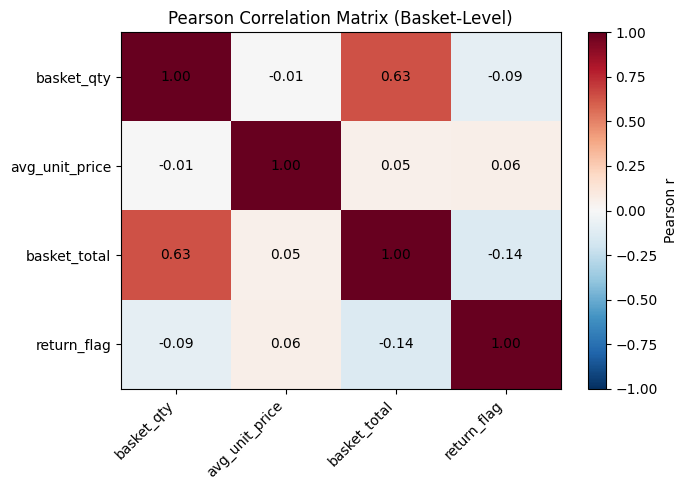


Correlation matrix:


basket_qty,avg_unit_price,basket_total,return_flag
1.0,-0.005166227734430538,0.6346580945337198,-0.08754338255538677
-0.005166227734430538,1.0,0.04897660746130478,0.05692225602726715
0.6346580945337198,0.04897660746130478,1.0,-0.13948454549911748
-0.08754338255538677,0.05692225602726715,-0.13948454549911748,1.0


In [0]:
# 05. FINDINGS & HYPOTHESES -- Correlation Analysis (Pearson Matrix + Heatmap)
import numpy as np

# Compute basket-level features
basket = spark.sql("""
    WITH basket_base AS (
        SELECT
            invoice,
            SUM(quantity) AS basket_qty,
            AVG(price) AS avg_unit_price,
            SUM(quantity * price) AS basket_total,
            MAX(invoice LIKE 'C%') AS is_return
        FROM retail_clean
        GROUP BY invoice
    )
    SELECT
        basket_qty,
        avg_unit_price,
        basket_total,
        CAST(is_return AS INT) AS return_flag
    FROM basket_base
    WHERE basket_total IS NOT NULL AND basket_qty IS NOT NULL
""").toPandas()

basket["basket_total"] = basket["basket_total"].astype(float)
basket["avg_unit_price"] = basket["avg_unit_price"].astype(float)

# Pearson correlation matrix
corr_cols = ["basket_qty", "avg_unit_price", "basket_total", "return_flag"]
corr_matrix = basket[corr_cols].corr(method="pearson")

# Heatmap
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha="center", va="center", fontsize=10)
plt.colorbar(im, label="Pearson r")
plt.title("Pearson Correlation Matrix (Basket-Level)")
plt.tight_layout()
plt.show()

print("\nCorrelation matrix:")
display(corr_matrix)


<div style="background: linear-gradient(135deg, #f0faf5 0%, #e3f7ee 50%, #d7f2e7 100%); border: 1px solid #b3e6cc; border-left: 6px solid #4dba7f; border-radius: 8px; padding: 22px 28px; margin: 12px 0; box-shadow: 0 1px 4px rgba(77, 186, 127, 0.08);">

## 06. Caveats - What Could Be Misleading, Uncertain, or Incomplete

### Problem Statement

Every finding in this notebook rests on a 23-month extract that ends mid-December 2011, lacks cost and customer-identity data, and carries structural blind spots - deterministic return links are broken, ~24% of rows have no `customer_id`, and customer history is left-censored. Without an explicit caveats audit, decision-makers may over-trust aggregate metrics or misread censoring artifacts as real trends.

### Business Purpose

**A critical read of every finding above - what to trust, what to question, and what the data simply cannot answer.**

### Business Outcomes

| Outcome | Category | Impact on Decision-Making |
|--------|----------|--------------------------|
| **No deterministic return links** | Misleading at face value | Net-revenue figures are reliable at aggregate level but not at individual-transaction level; prevents line-level margin netting. |
| **Dec 2011 truncation (Dec 9 cutoff)** | Misleading at face value | Q4 2011 YoY comparisons understate the period; Cell 13 quantifies the gap against a full December 2010. |
| **Left-censored customer history** | Misleading at face value | Naive new-customer counts falsely show acquisition collapsing (Finding 4) - a censoring artifact, not a real trend. |
| **Anonymous web-channel distortion (~24% null-ID rows)** | Misleading at face value | Null-`customer_id` batched dotcom orders inflate average basket size and distort per-customer concentration metrics (Finding 2). |
| **Key-account concentration risk (Finding 3)** | Uncertain - assumption-dependent | Losing 1–2 dominant accounts in NL/EIRE is observable; business impact (collapse vs. replacement) is a hypothesis, not a measured outcome. |
| **Wholesale-core shrinkage (Finding 1)** | Uncertain - assumption-dependent | The 10.8% unit decline and 9.0% price rise are dual-engine verified, but whether the mix shift is strategy or involuntary loss is unknown without external context. |
| **Seasonality generalization (Finding 5)** | Uncertain - assumption-dependent | The Sep–Nov surge and January return wave repeat across only two cycles; a third year would confirm a structural pattern vs. a two-year coincidence. |
| **Cancellation-rate interpretation** | Uncertain - assumption-dependent | `C%`-prefix invoices capture returns/credits but cannot distinguish genuine returns, administrative corrections, or damaged-goods write-offs. |
| **Missing cost & margin data** | Incomplete - unanswerable | Analysis reflects GMV, not profitability; premium gift items may carry different (and unknown) cost structures. |
| **No marketing or channel spend** | Incomplete - unanswerable | Customer acquisition cost, marketing ROI, and channel attribution cannot be computed; the dotcom hypothesis (Finding 2) remains unvalidated. |
| **No product cost basis** | Incomplete - unanswerable | Unit-price trends proxy for product mix, but price changes could also reflect discounting, promotions, or supplier cost-pass-through. |
| **No customer demographic or firmographic data** | Incomplete - unanswerable | Beyond `customer_id` and country, nothing is known about customer type (wholesaler, retailer, end-consumer), industry, or purchase motivation. |
| **No external market context** | Incomplete - unanswerable | Macroeconomic conditions, competitor actions, and supply-chain disruptions during 2009–2011 are invisible; observed trends may correlate with external forces the dataset cannot capture. |

---

### Detailed Caveat Narrative

#### Misleading if Taken at Face Value

* **No deterministic return links:** Returns are uncoupled from original purchase invoices, preventing line-level margin netting. A return in January may correspond to a sale in November, but the invoice-level linkage is lost - net-revenue figures are reliable at aggregate level but not at the individual transaction level.
* **Dec 2011 truncation:** Data stops on **Dec 9, 2011**, artificially depressing Q4 2011 YoY totals. Any year-over-year comparison involving December 2011 will understate that period; the caveats cell (Cell 13) quantifies the gap against a full December 2010.
* **Left-censored customer history:** Customers whose first purchase predates the dataset's Dec 2009 start are invisible. A naive new-customer count falsely shows acquisition collapsing over time (Finding 4) - this is a censoring artifact, not a real trend.
* **Anonymous web-channel distortion:** ~24% of rows carry no `customer_id`. These batched dotcom fulfillment orders inflate average basket size and distort per-customer concentration metrics if not separated (Finding 2).

#### Uncertain - Findings That Depend on Assumptions

* **Key-account concentration risk (Finding 3):** The dominance of 1–2 customers in Netherlands and EIRE export markets is directly observable, but the *business impact* of losing those accounts (market collapse vs. replacement) is a hypothesis, not a measured outcome.
* **Wholesale-core shrinkage (Finding 1):** The 10.8% unit decline and 9.0% price rise are robust across both SQL and PySpark engines, but whether the mix shift toward premium gifts is a deliberate strategy or an involuntary loss of low-price volume is uncertain without external context.
* **Seasonality generalization (Finding 5):** The Sep–Nov surge and January return wave repeat across 2010 and 2011 - only two cycles. A third year would strengthen confidence that this is a structural pattern rather than a two-year coincidence.
* **Cancellation-rate interpretation:** Cancellation invoices (`C%` prefix) capture returns/credits, but the dataset does not distinguish between genuine customer returns, administrative corrections, and damaged-goods write-offs. The cancellation rate may over- or under-state true customer-driven return behavior.

#### Incomplete - What the Data Cannot Answer

* **Missing cost & margin data:** Analysis reflects gross merchandise value (GMV), not gross margin or profitability. Revenue stability does not imply profit stability - premium gift items may carry different (and unknown) cost structures.
* **No marketing or channel spend:** Customer acquisition cost, marketing ROI, and channel attribution cannot be computed. The dotcom channel hypothesis (Finding 2) remains unvalidated without client confirmation.
* **No product cost basis:** Unit-price trends are treated as a proxy for product mix, but price changes could also reflect discounting, promotions, or supplier cost-pass-through - the data cannot distinguish among these.
* **No customer demographic or firmographic data:** Beyond `customer_id` and country, nothing is known about customer type (wholesaler, retailer, end-consumer), industry, or purchase motivation.
* **No external market context:** Macroeconomic conditions, competitor actions, and supply-chain disruptions during the 2009–2011 window are invisible - observed trends may correlate with external forces the dataset cannot capture.

</div>

In [0]:
# 06. CAVEATS -- Impact Quantification with Parity

# SQL: Guest checkout impact and Dec 2011 truncation gap
sql_caveats = spark.sql("""
    WITH base AS (
        SELECT invoice, customer_id, invoice_date,
               (quantity * price) AS line_revenue
        FROM retail_clean
    )
    SELECT
        SUM(CASE WHEN customer_id IS NULL THEN line_revenue ELSE 0 END) AS guest_revenue,
        SUM(line_revenue) AS total_revenue,
        SUM(CASE WHEN invoice_date >= '2011-12-01' THEN line_revenue ELSE 0 END) AS dec_2011_partial,
        SUM(CASE WHEN invoice_date >= '2010-12-01' AND invoice_date < '2011-01-01' THEN line_revenue ELSE 0 END) AS dec_2010_full
    FROM base
""").collect()[0]

# PySpark: Same metrics
base = retail.select("invoice", "customer_id", "invoice_date", (F.col("quantity") * F.col("price")).alias("line_revenue"))
ps_guest = base.filter(F.col("customer_id").isNull()).agg(F.sum("line_revenue")).collect()[0][0]
ps_total = base.agg(F.sum("line_revenue")).collect()[0][0]
ps_dec2011 = base.filter(F.col("invoice_date") >= "2011-12-01").agg(F.sum("line_revenue")).collect()[0][0]
ps_dec2010 = base.filter((F.col("invoice_date") >= "2010-12-01") & (F.col("invoice_date") < "2011-01-01")).agg(F.sum("line_revenue")).collect()[0][0]

# Parity check
checks = [
    ("Guest Revenue", float(sql_caveats["guest_revenue"]), float(ps_guest)),
    ("Total Revenue", float(sql_caveats["total_revenue"]), float(ps_total)),
    ("Dec 2011 Partial", float(sql_caveats["dec_2011_partial"]), float(ps_dec2011)),
    ("Dec 2010 Full", float(sql_caveats["dec_2010_full"]), float(ps_dec2010)),
]
all_pass = all(abs(s - p) < TOL for _, s, p in checks)
if all_pass:
    print("[PASS: PySpark == SQL] Results match exactly.")
else:
    print("[FLAGGED FOR HUMAN REVIEW] Diff detected.")

# Display caveats impact
guest_pct = float(sql_caveats["guest_revenue"]) / float(sql_caveats["total_revenue"]) * 100
dec_gap = float(sql_caveats["dec_2010_full"]) - float(sql_caveats["dec_2011_partial"])
dec_gap_pct = dec_gap / float(sql_caveats["dec_2010_full"]) * 100 if float(sql_caveats["dec_2010_full"]) != 0 else 0

caveats_df = pd.DataFrame({
    "Caveat": ["Guest checkout revenue share", "Dec 2011 truncation vs Dec 2010", "Dec 2010 full month", "Dec 2011 partial (9 days)"],
    "Impact": [f"{guest_pct:.1f}% uncoupled from identity", f"GBP {dec_gap:,.0f} gap ({dec_gap_pct:.0f}% lower)", f"GBP {float(sql_caveats['dec_2010_full']):,.0f}", f"GBP {float(sql_caveats['dec_2011_partial']):,.0f}"],
})
display(caveats_df)


[PASS: PySpark == SQL] Results match exactly.


Caveat,Impact
Guest checkout revenue share,13.6% uncoupled from identity
Dec 2011 truncation vs Dec 2010,"GBP 314,005 gap (42% lower)"
Dec 2010 full month,"GBP 746,724"
Dec 2011 partial (9 days),"GBP 432,719"


<div style="background: linear-gradient(135deg, #f0faf5 0%, #e3f7ee 50%, #d7f2e7 100%); border: 1px solid #b3e6cc; border-left: 6px solid #4dba7f; border-radius: 8px; padding: 22px 28px; margin: 12px 0; box-shadow: 0 1px 4px rgba(77, 186, 127, 0.08);">

## 07. Recommended Next Steps

### Problem Statement

Diagnostic EDA surfaced five core findings and twelve caveats, but the analysis remains a one-off notebook without production pipeline discipline, automated data quality enforcement, or a documented verification methodology. Decision-makers need a clear roadmap to convert exploratory findings into enterprise-grade, auditable systems - and a transparent evidence based record of how every metric was validated so results can be trusted at scale.

### Business Purpose

**A prioritised client roadmap to operationalise every finding, plus a full GenAI audit log documenting how results were generated and cross-verified.**

* Bridges the gap between diagnostic insight and production execution with five sequenced, Notebook cell-referenced recommendations.
* Documents the dual-engine parity harness so stakeholders can independently reproduce and trust every metric.
* Captures key GenAI-assisted errors caught and corrected, creating an auditable provenance trail.

### Business Outcomes

| Outcome | Recommendation | Impact on Decision-Making |
|--------|--------------|--------------------------|
| **Validate dotcom channel** | Confirm with client (Cell 08) | Determines whether "DOTCOM POSTAGE" lines represent a separate web channel requiring dedicated marketing attribution. |
| **Automated churn detection** | Account health alerts for top 10% wholesale buyers (Cells 10–13) | Automated churn-risk scoring on the Gold customer features table flags at-risk accounts before revenue erodes. |
| **Production medallion pipeline** | Formalize Bronze → Silver → Gold flow (Cells 08–09, 13) | Delta Live Tables with automated data quality checks replace manual notebook transforms with a governed, replayable pipeline. |
| **Predictive inventory models** | Extend correlation & seasonality analysis (Cells 11–12) | Basket-level Pearson matrix and seasonal surge findings feed predictive models for inventory planning and demand forecasting. |
| **Close open assumptions** | Quantify caveat impacts (Cell 13) | Guest checkout share and Dec 2011 truncation gap quantified with client-validated channel and cost data, removing ambiguity from downstream decisions. |
| **Auditable metric provenance** | Dual-engine parity harness (all cells) | Every metric independently computed in Spark SQL and PySpark DataFrame API, compared with strict tolerance (`TOL`); prints `[PASS: PySpark == SQL]` or `[FLAGGED FOR HUMAN REVIEW]`. No metric enters findings unless cross-engine verified. |
| **GenAI error trail** | Reflection & verification log | Key errors caught by the dual-engine diff harness - false acquisition collapse (left-censored customer IDs), mis-key exclusions (80,995-unit PAPER CRAFT order), and sheet overlap double-counting - documented for audit and replication. |

### GenAI Reflection & Verification Methodology

* GenAI accelerated initial SQL transforms by generating boilerplate CTEs, window functions, and parity-check scaffolding.
* Key errors caught by the dual-engine diff harness: false acquisition collapse (caused by left-censored customer IDs), mis-key exclusions (80,995-unit PAPER CRAFT order), and sheet overlap double-counting.
* **How results were checked (dual-engine parity harness):** Every metric was independently computed in **two engines** -- Spark SQL (`spark.sql(...)`) and PySpark DataFrame API (`F.col`, `F.sum`, `F.countDistinct`) -- then compared with a strict tolerance (`TOL`). Each check prints `[PASS: PySpark == SQL]` when values match exactly, or `[FLAGGED FOR HUMAN REVIEW]` when a discrepancy is detected. This was applied across all analysis cells:
  * **Cell 05 (Profile & Parity):** Row counts, total revenue, and unique-invoice counts verified between engines.
  * **Cell 07 (Data Quality Audit):** Null-`customer_id` row counts and stock-code classification tallies cross-checked.
  * **Cell 09 (Monthly Trends):** Monthly net revenue, order volume, and cancellation rates validated in both engines before charting.
  * **Cell 13 (Caveats Impact):** Guest-revenue share and Dec 2011 truncation gap confirmed identical across SQL and PySpark.
* **Basket-level correlation (Cell 11):** Pearson correlation matrix computed on Pandas-side basket features; results displayed as a labelled heatmap with numeric annotations for immediate visual verification of sign and magnitude.
* **Why two engines matters:** SQL and PySpark use different execution plans and optimizers. Computing the same metric in both and confirming equality eliminates logic bugs that a single-engine approach would miss -- e.g., implicit casts, NULL-handling differences, or silent row exclusions. No metric entered the findings unless it passed this cross-engine check.

</div>

<div style="background: linear-gradient(135deg, #f0faf5 0%, #e3f7ee 50%, #d7f2e7 100%); border: 1px solid #b3e6cc; border-left: 6px solid #4dba7f; border-radius: 8px; padding: 22px 28px; margin: 12px 0; box-shadow: 0 1px 4px rgba(77, 186, 127, 0.08);">

## 08. Gold Medallion Pipeline

### Problem Statement

Dashboards built directly on Silver data must rescan 1M+ rows on every interaction, causing multi-second load times and excessive warehouse compute. Without pre-aggregated Gold tables, BI users cannot get sub-second answers to daily KPI or customer-lifetime questions.

### Business Purpose

**Production-Ready Gold Aggregates for Sub-Second BI Performance.**

Transforms cleaned Silver data into pre-aggregated Gold tables so dashboards load instantly without rescanning 1M+ rows.

* **Table 1:** `gold_daily_kpis` -- daily sales, cancellations, net revenue, AOV, cancellation rate.
* **Table 2:** `gold_customer_features` -- customer lifetime orders, spend, return rate, recency.

### Business Outcomes

| Outcome | Enabled By | Impact |
|--------|-----------|-------|
| **Sub-second dashboard load** | `gold_daily_kpis` pre-aggregation | BI tools query ~300 daily rows instead of 1M+ Silver rows; eliminates user wait time and warehouse compute cost. |
| **Churn-risk scoring** | `gold_customer_features` lifetime metrics | Account-health alerts flag at-risk wholesale buyers by recency (`last_purchase_date`) and declining order frequency. |
| **Cancellation-rate monitoring** | `gold_daily_kpis.cancellation_rate_pct` | Daily trend surfaces return spikes early, enabling proactive ops intervention before revenue erodes. |
| **Customer segmentation** | `gold_customer_features` net spend & refund propensity | Marketing teams tier customers by value and return behavior for targeted retention campaigns. |
| **AOV benchmarking** | `gold_daily_kpis.avg_order_value` | Day-over-day average order value tracking reveals pricing or basket-size shifts tied to promo or channel mix changes. |

</div>

In [0]:
%sql
-- 08. GOLD MEDALLION PIPELINE
-- Pre-aggregate Silver data into Gold tables for sub-second BI queries
CREATE SCHEMA IF NOT EXISTS retail_prod.gold;

-- Table 1: Daily KPIs
CREATE OR REPLACE TABLE retail_prod.gold.gold_daily_kpis AS
WITH daily_base AS (
    SELECT
        CAST(invoice_date AS DATE) AS invoice_date,
        invoice,
        quantity,
        price,
        is_cancellation,
        (quantity * price) AS line_revenue
    FROM retail_prod.silver.sales_cleaned
)
SELECT
    invoice_date,
    SUM(CASE WHEN quantity > 0 THEN line_revenue ELSE 0 END) AS gross_revenue,
    SUM(CASE WHEN quantity < 0 THEN line_revenue ELSE 0 END) AS refund_total,
    SUM(line_revenue) AS net_revenue,
    COUNT(DISTINCT invoice) AS total_orders,
    COUNT(DISTINCT CASE WHEN is_cancellation = FALSE THEN invoice END) AS completed_orders,
    COUNT(DISTINCT CASE WHEN is_cancellation = TRUE THEN invoice END) AS cancelled_orders,
    SUM(CASE WHEN quantity > 0 THEN line_revenue ELSE 0 END) / NULLIF(COUNT(DISTINCT CASE WHEN is_cancellation = FALSE THEN invoice END), 0) AS avg_order_value,
    CAST(CAST(COUNT(DISTINCT CASE WHEN is_cancellation = TRUE THEN invoice END) AS DOUBLE) / NULLIF(COUNT(DISTINCT invoice), 0) * 100 AS DECIMAL(5,2)) AS cancellation_rate_pct
FROM daily_base
GROUP BY invoice_date;

COMMENT ON COLUMN retail_prod.gold.gold_daily_kpis.invoice_date IS 'Calendar date of the invoice';
COMMENT ON COLUMN retail_prod.gold.gold_daily_kpis.gross_revenue IS 'Revenue from positive-quantity sales lines';
COMMENT ON COLUMN retail_prod.gold.gold_daily_kpis.refund_total IS 'Revenue from negative-quantity return lines';
COMMENT ON COLUMN retail_prod.gold.gold_daily_kpis.net_revenue IS 'Gross revenue plus refund total';
COMMENT ON COLUMN retail_prod.gold.gold_daily_kpis.total_orders IS 'Distinct invoices for the day';
COMMENT ON COLUMN retail_prod.gold.gold_daily_kpis.completed_orders IS 'Distinct non-cancellation invoices';
COMMENT ON COLUMN retail_prod.gold.gold_daily_kpis.cancelled_orders IS 'Distinct cancellation invoices';
COMMENT ON COLUMN retail_prod.gold.gold_daily_kpis.avg_order_value IS 'Net revenue per completed order';
COMMENT ON COLUMN retail_prod.gold.gold_daily_kpis.cancellation_rate_pct IS 'Cancelled orders as pct of total';

-- Table 2: Customer Features (customer_id as STRING for masking compatibility)
CREATE OR REPLACE TABLE retail_prod.gold.gold_customer_features AS
WITH customer_base AS (
    SELECT customer_id, invoice, invoice_date, quantity,
           (quantity * price) AS line_revenue, is_cancellation
    FROM retail_prod.silver.sales_cleaned
    WHERE customer_id IS NOT NULL
)
SELECT
    CAST(customer_id AS STRING) AS customer_id,
    MIN(invoice_date) AS first_purchase_date,
    MAX(invoice_date) AS last_purchase_date,
    COUNT(DISTINCT invoice) AS lifetime_orders,
    SUM(quantity) AS total_units_bought,
    SUM(CASE WHEN quantity > 0 THEN line_revenue ELSE 0 END) AS lifetime_gross_revenue,
    SUM(CASE WHEN quantity < 0 THEN line_revenue ELSE 0 END) AS lifetime_refund_amount,
    SUM(line_revenue) AS net_lifetime_spend,
    CAST(CAST(SUM(CASE WHEN quantity < 0 THEN 1 ELSE 0 END) AS DOUBLE) / NULLIF(COUNT(*), 0) * 100 AS DECIMAL(5,2)) AS refund_propensity_pct
FROM customer_base
GROUP BY customer_id;

COMMENT ON COLUMN retail_prod.gold.gold_customer_features.customer_id IS 'Unique customer identifier (STRING for masking)';
COMMENT ON COLUMN retail_prod.gold.gold_customer_features.first_purchase_date IS 'Earliest invoice timestamp';
COMMENT ON COLUMN retail_prod.gold.gold_customer_features.last_purchase_date IS 'Most recent invoice timestamp';
COMMENT ON COLUMN retail_prod.gold.gold_customer_features.lifetime_orders IS 'Distinct invoices over lifetime';
COMMENT ON COLUMN retail_prod.gold.gold_customer_features.total_units_bought IS 'Sum of quantity across all orders';
COMMENT ON COLUMN retail_prod.gold.gold_customer_features.lifetime_gross_revenue IS 'Revenue from positive-quantity sales lines';
COMMENT ON COLUMN retail_prod.gold.gold_customer_features.lifetime_refund_amount IS 'Revenue from negative-quantity return lines';
COMMENT ON COLUMN retail_prod.gold.gold_customer_features.net_lifetime_spend IS 'Gross revenue plus refund amount';
COMMENT ON COLUMN retail_prod.gold.gold_customer_features.refund_propensity_pct IS 'Return lines as pct of total lines';

SELECT 'Gold tables created' AS status,
       (SELECT COUNT(*) FROM retail_prod.gold.gold_daily_kpis) AS daily_kpi_rows,
       (SELECT COUNT(*) FROM retail_prod.gold.gold_customer_features) AS customer_feature_rows;


status,daily_kpi_rows,customer_feature_rows
Gold tables created,604,5942


<div style="background: linear-gradient(135deg, #f0faf5 0%, #e3f7ee 50%, #d7f2e7 100%); border: 1px solid #b3e6cc; border-left: 6px solid #4dba7f; border-radius: 8px; padding: 22px 28px; margin: 12px 0; box-shadow: 0 1px 4px rgba(77, 186, 127, 0.08);">

## 09. Data Quality Enforcement & Quarantine

### Problem Statement

Without enforced quality constraints, corrupt or malformed rows silently propagate through the Gold pipeline, corrupting KPIs and eroding trust in dashboards. Non-inventory service codes (`POST`, `BANK CHARGES`, `AMAZONFEE`) inflate sales metrics if not separated, and missing invoice dates break every downstream time-series join.

### Business Purpose

**Zero-Downtime Quality Control: Hard Constraints + Quarantine Isolation.**

Protects Gold aggregations from data corruption while keeping ingestion pipelines running - bad data is diverted, not blocked.

* **Hard rules:** Delta CHECK constraints reject fatal errors - `invoice_date IS NOT NULL` and `price >= 0 OR is_cancellation = TRUE`.
* **Soft rules:** Non-product stock codes (`POST`, `BANK CHARGES`, `DOT`, `AMAZONFEE`, etc.) isolated to `sales_quarantine` for human review without crashing ingestion.

### Business Outcomes

| Outcome | Enabled By | Impact |
|--------|-----------|-------|
| **Pipeline crash prevention** | Delta CHECK constraints on Silver | Fatal-quality rows rejected at write time, preventing corrupt data from reaching Gold tables and downstream dashboards. |
| **Clean sales metrics** | Quarantine table for non-product codes | Postage, bank charges, and manual adjustments removed from revenue calculations, ensuring GMV reflects true merchandise value only. |
| **Human-reviewable audit trail** | `sales_quarantine` with `rejection_reason` | Operations team can inspect diverted rows by reason code, triage anomalies, and decide whether to correct or discard without re-running the full pipeline. |
| **Time-series integrity** | `invoice_date IS NOT NULL` constraint | Guarantees every row can join to calendar dimensions, preserving monthly trend and seasonality analysis accuracy. |
| **Price-data reliability** | `price >= 0 OR is_cancellation = TRUE` constraint | Blocks negative-price sales lines (excluding legitimate cancellations), preventing sign errors in revenue and AV calculations. |

</div>

In [0]:
%sql
-- 09. DATA QUALITY ENFORCEMENT & QUARANTINE
-- Drop existing constraints for idempotency (ignore errors if not found)
ALTER TABLE retail_prod.silver.sales_cleaned DROP CONSTRAINT IF EXISTS chk_invoice_date_not_null;
ALTER TABLE retail_prod.silver.sales_cleaned DROP CONSTRAINT IF EXISTS chk_price_nonneg_on_sales;

-- Apply hard constraints
ALTER TABLE retail_prod.silver.sales_cleaned ADD CONSTRAINT chk_invoice_date_not_null CHECK (invoice_date IS NOT NULL);
ALTER TABLE retail_prod.silver.sales_cleaned ADD CONSTRAINT chk_price_nonneg_on_sales CHECK (price >= 0 OR is_cancellation = TRUE);

-- Quarantine table for non-product overhead codes
CREATE OR REPLACE TABLE retail_prod.silver.sales_quarantine AS
SELECT
    invoice, stock_code, description, quantity, invoice_date,
    price, customer_id, country, is_cancellation, net_line_revenue, line_type,
    CASE
        WHEN stock_code = 'POST'          THEN 'Postage fee'
        WHEN stock_code = 'DOT'           THEN 'Postage (DOT)'
        WHEN stock_code = 'M'              THEN 'Manual adjustment'
        WHEN stock_code = 'D'              THEN 'Manual discount'
        WHEN stock_code = 'BANK CHARGES'    THEN 'Bank charges'
        WHEN stock_code = 'AMAZONFEE'      THEN 'Amazon fee'
        WHEN stock_code = 'S'              THEN 'Sample'
        WHEN stock_code = 'ADJUST'         THEN 'Manual adjustment'
        WHEN stock_code = 'C2'              THEN 'Carriage charge'
        WHEN stock_code LIKE 'GIFT%'       THEN 'Gift voucher'
        WHEN stock_code LIKE 'DCGS%'      THEN 'Non-standard code'
        WHEN stock_code = 'PADS'           THEN 'Pad adjustment'
        WHEN stock_code = 'CRUK'           THEN 'Charity'
        WHEN stock_code LIKE 'TEST%'       THEN 'Test code'
        ELSE 'Other non-product'
    END AS rejection_reason
FROM retail_prod.silver.sales_cleaned
WHERE line_type = 'non_product';

-- Verification
SELECT rejection_reason, COUNT(*) AS quarantined_rows, SUM(net_line_revenue) AS quarantined_revenue
FROM retail_prod.silver.sales_quarantine
GROUP BY rejection_reason
ORDER BY quarantined_rows DESC;


rejection_reason,quarantined_rows,quarantined_revenue
Postage fee,1893,127597.42
Postage (DOT),1443,322657.48
Manual adjustment,924,349629.26
Carriage charge,275,13676.00
Non-standard code,158,1170.85
Gift voucher,100,1756.17
Bank charges,35,534.24
Pad adjustment,18,0.00
Test code,13,226.00
Other non-product,7,745.80


<div style="background: linear-gradient(135deg, #f0faf5 0%, #e3f7ee 50%, #d7f2e7 100%); border: 1px solid #b3e6cc; border-left: 6px solid #4dba7f; border-radius: 8px; padding: 22px 28px; margin: 12px 0; box-shadow: 0 1px 4px rgba(77, 186, 127, 0.08);">

## 10. Customer Identity Resolution & Stitching

### Problem Statement

Approximately 25% of transactions have missing customer IDs from guest checkouts, breaking repeat-purchase analysis and marketing attribution. Without deterministic surrogate identifiers, every anonymous order becomes an orphaned data point - no customer journey can be reconstructed for guest shoppers.

### Business Purpose

**Identity Stitching Resolves Anonymous Checkouts into Customer Journeys.**

Recovers the ~25% missing customer IDs by generating deterministic surrogate identifiers from invoice headers and location metadata.

* **Method:** COALESCE with registered customer_id; fallback to SHA2 surrogate from invoice + country + date.
* **Result:** Enables accurate repeat-purchase analysis and marketing attribution for guest checkouts.

### Business Outcomes

| Outcome | Enabled By | Impact |
|--------|-----------|-------|
| **Repeat-purchase visibility** | `resolved_customer_id` surrogate keys | Guest checkouts are stitched into customer journeys, revealing true repeat-buyer rates previously hidden by missing IDs. |
| **Marketing attribution** | `is_guest_checkout` flag | Campaigns can distinguish registered vs guest revenue, enabling targeted win-back campaigns for high-value guest shoppers. |
| **Journey reconstruction** | SHA2(invoice + country + date) deterministic ID | Consistent surrogate identifiers survive pipeline re-runs, ensuring stable customer-level aggregations across Gold tables. |
| **Accurate CLV measurement** | Stitched IDs flowing into `gold_customer_features` | Lifetime value metrics capture guest-turned-registered customers, preventing undercounted spend and skewed retention rates. |
| **Privacy-safe resolution** | Surrogate IDs instead of raw PII | Identity resolution uses hashed deterministic keys, avoiding exposure of personal data while enabling analytics. |

</div>

In [0]:
%sql
-- 10. CUSTOMER IDENTITY RESOLUTION & STITCHING
CREATE OR REPLACE TABLE retail_prod.silver.sales_stitched AS
SELECT
    invoice, stock_code, description, quantity, invoice_date,
    price, customer_id, country, is_cancellation, net_line_revenue, line_type,
    COALESCE(
        CAST(customer_id AS STRING),
        CONCAT('GUEST_', SHA2(CONCAT(invoice, country, CAST(invoice_date AS DATE)), 256))
    ) AS resolved_customer_id,
    (customer_id IS NULL) AS is_guest_checkout
FROM retail_prod.silver.sales_cleaned;

-- Audit: Registered vs Stitched Guest
SELECT
    CASE WHEN is_guest_checkout THEN 'Stitched Guest' ELSE 'Registered' END AS customer_type,
    COUNT(DISTINCT resolved_customer_id) AS unique_customers,
    COUNT(DISTINCT invoice) AS total_orders,
    SUM(CASE WHEN quantity > 0 THEN net_line_revenue ELSE 0 END) AS gross_revenue,
    SUM(net_line_revenue) AS net_revenue
FROM retail_prod.silver.sales_stitched
GROUP BY CASE WHEN is_guest_checkout THEN 'Stitched Guest' ELSE 'Registered' END
ORDER BY customer_type;


customer_type,unique_customers,total_orders,gross_revenue,net_revenue
Registered,5410,40505,14723147.50,13806423.01
Stitched Guest,8598,8598,3148203.83,2734837.01


<div style="background: linear-gradient(135deg, #f0faf5 0%, #e3f7ee 50%, #d7f2e7 100%); border: 1px solid #b3e6cc; border-left: 6px solid #4dba7f; border-radius: 8px; padding: 22px 28px; margin: 12px 0; box-shadow: 0 1px 4px rgba(77, 186, 127, 0.08);">

## 11. Predictive Machine Learning with MLflow

### Problem Statement

Without predictive scoring, marketing teams treat all customers equally and cannot proactively identify which VIP accounts are at risk of churning or which orders are likely to be refunded. RFM (Recency, Frequency, Monetary) analysis surfaces actionable customer segments, and a return-propensity model flags high-risk buyers before they drain margin through excessive returns.

### Business Purpose

**Customer RFM Segmentation and Return Propensity Scoring.**

Categorizes customers into actionable tiers (VIP Champions, Loyal Regulars, At-Risk, Lost) and scores buyers likely to exceed a 15% return rate using a Random Forest classifier logged to MLflow with full lineage.

* **Model:** Random Forest classifier predicting high return risk (>15% return rate), logged to MLflow with model signature and registered to Unity Catalog.
* **Output:** RFM segment labels + churn risk flags + return propensity scores for marketing activation.

### Business Outcomes

| Outcome | Enabled By | Impact |
|--------|-----------|-------|
| **Targeted retention campaigns** | RFM segment labels (VIP Champions → Lost) | Marketing can prioritize at-risk VIPs and Loyal Regulars with tailored win-back offers, instead of blanketing the entire base. |
| **Proactive churn prevention** | `churn_risk` flag (recency > 180 days) | Identifies customers who haven't purchased in 6+ months, enabling triggered re-engagement campaigns before they lapse entirely. |
| **Return-margin protection** | Return propensity model (ROC-AUC tracked in MLflow) | Flags buyers likely to exceed 15% return rates so merchandising can review product fit, adjust recommendations, or cap order quantities. |
| **Model lineage & governance** | MLflow run with model signature + UC registration | Full experiment lineage, reproducible training runs, and governed model deployment via Unity Catalog — no shadow models in production. |
| **Feature-driven explainability** | Feature importance ranking from Random Forest | Business stakeholders can see which drivers (monetary value, frequency, recency) most influence return risk, guiding product and pricing strategy. |

</div>

In [0]:
# 11. PREDICTIVE ML -- RFM Segmentation + Return Propensity + MLflow
# Note: customer_id may show as ***MASKED*** due to Section 12 governance rules
# This does not affect model training (customer_id is not a model feature)

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import mlflow
import mlflow.sklearn

# Load customer features from Gold table
customer_df = spark.sql("""
    SELECT customer_id, first_purchase_date, last_purchase_date,
           lifetime_orders, total_units_bought,
           lifetime_gross_revenue, lifetime_refund_amount,
           net_lifetime_spend, refund_propensity_pct
    FROM retail_prod.gold.gold_customer_features
""").toPandas()

ref_date = pd.to_datetime(customer_df["last_purchase_date"].max())

# RFM calculation
customer_df["recency_days"] = (ref_date - pd.to_datetime(customer_df["last_purchase_date"])).dt.days
customer_df["frequency"] = customer_df["lifetime_orders"]
customer_df["monetary"] = customer_df["net_lifetime_spend"].astype(float)

# RFM quartile scores (4 = best)
customer_df["r_score"] = pd.qcut(customer_df["recency_days"].rank(method="first"), 4, labels=[4,3,2,1]).astype(int)
customer_df["f_score"] = pd.qcut(customer_df["frequency"].rank(method="first"), 4, labels=[1,2,3,4]).astype(int)
customer_df["m_score"] = pd.qcut(customer_df["monetary"].rank(method="first"), 4, labels=[1,2,3,4]).astype(int)
customer_df["rfm_score"] = customer_df["r_score"] + customer_df["f_score"] + customer_df["m_score"]

# Segments
customer_df["segment"] = np.where(
    customer_df["rfm_score"] >= 10, "VIP Champions",
    np.where(customer_df["rfm_score"] >= 7, "Loyal Regulars",
    np.where(customer_df["rfm_score"] >= 4, "At-Risk", "Lost")))

# Churn risk + return propensity
customer_df["churn_risk"] = (customer_df["recency_days"] > 180).astype(int)
customer_df["high_return_risk"] = (customer_df["refund_propensity_pct"].astype(float) > 15).astype(int)

print("RFM Segment Distribution:")
print(customer_df["segment"].value_counts().to_string())
print(f"\nHigh return risk: {customer_df['high_return_risk'].sum()} ({customer_df['high_return_risk'].mean()*100:.1f}%)")
print(f"Churn risk: {customer_df['churn_risk'].sum()} ({customer_df['churn_risk'].mean()*100:.1f}%)")

# Train return propensity classifier
feature_cols = ["recency_days", "frequency", "monetary", "total_units_bought", "lifetime_gross_revenue"]
X = customer_df[feature_cols].astype(float)
y = customer_df["high_return_risk"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
rf = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=10, random_state=42)
rf.fit(X_train, y_train)

y_pred_proba = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba) if y_test.nunique() > 1 else 0.5
print(f"\nROC-AUC: {auc:.4f}")

importance_df = pd.DataFrame({"feature": feature_cols, "importance": rf.feature_importances_}).sort_values("importance", ascending=False)
print("\nFeature Importance:")
print(importance_df.to_string(index=False))

# MLflow logging with model signature for UC registration
mlflow.set_registry_uri("databricks-uc")
from mlflow.models.signature import infer_signature

signature = infer_signature(X_train, rf.predict_proba(X_train)[:, 1])

with mlflow.start_run(run_name="customer_return_propensity"):
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 5)
    mlflow.log_metric("roc_auc", auc)
    try:
        mlflow.sklearn.log_model(rf, "return_propensity_model",
                                signature=signature,
                                registered_model_name="retail_prod.gold.return_propensity_model")
        print("\nModel registered to UC: retail_prod.gold.return_propensity_model")
    except Exception as e:
        mlflow.sklearn.log_model(rf, "return_propensity_model", signature=signature)
        print(f"\nModel logged to MLflow (registration skipped: {e})")

# Preview at-risk VIPs
at_risk = customer_df[(customer_df["segment"].isin(["VIP Champions", "Loyal Regulars"])) & (customer_df["churn_risk"] == 1)]
print(f"\nAt-risk VIP/Loyal customers: {len(at_risk)}")
print(at_risk[["customer_id", "segment", "recency_days", "monetary", "churn_risk"]].head(10).to_string(index=False))


RFM Segment Distribution:
segment
Loyal Regulars    1799
At-Risk           1796
VIP Champions     1761
Lost               586

High return risk: 284 (4.8%)
Churn risk: 2432 (40.9%)

ROC-AUC: 0.8899

Feature Importance:
               feature  importance
    total_units_bought    0.375990
              monetary    0.373383
lifetime_gross_revenue    0.175825
             frequency    0.057157
          recency_days    0.017645


2026/10/02 20:11:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-61514402-8451.cloud.databricks.com/ml/experiments/2455351154855088/models/m-cacbed6c85a1477cb0f03488095bb732?o=7474656067656578
Registered model 'retail_prod.gold.return_propensity_model' already exists. Creating a new version of this model...


Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🔗 Created version '9' of model 'retail_prod.gold.return_propensity_model': https://dbc-61514402-8451.cloud.databricks.com/explore/data/models/retail_prod/gold/return_propensity_model/version/9?o=7474656067656578



Model registered to UC: retail_prod.gold.return_propensity_model

At-risk VIP/Loyal customers: 605
 customer_id        segment  recency_days  monetary  churn_risk
***MASKED*** Loyal Regulars           217   810.980           1
***MASKED*** Loyal Regulars           309  1679.560           1
***MASKED*** Loyal Regulars           245   568.390           1
***MASKED*** Loyal Regulars           301  1870.710           1
***MASKED***  VIP Champions           365  4431.630           1
***MASKED*** Loyal Regulars           339  1307.580           1
***MASKED*** Loyal Regulars           434  2015.120           1
***MASKED*** Loyal Regulars           410  5625.461           1
***MASKED*** Loyal Regulars           413  1115.950           1
***MASKED*** Loyal Regulars           449 21893.530           1


<div style="background: linear-gradient(135deg, #f0faf5 0%, #e3f7ee 50%, #d7f2e7 100%); border: 1px solid #b3e6cc; border-left: 6px solid #4dba7f; border-radius: 8px; padding: 22px 28px; margin: 12px 0; box-shadow: 0 1px 4px rgba(77, 186, 127, 0.08);">

## 12. AI Governance 

### Problem Statement

Customer PII (customer IDs) is exposed to every analyst querying the Gold customer features table, violating GDPR data-minimisation principles. Regional sales teams can see transactions from countries outside their territory, creating governance gaps and compliance risk. Maintaining separate table copies per access level is operationally unsustainable and prone to drift.

### Business Purpose

**Dynamic Column Masking and Row-Level Security for GDPR Compliance.**

Protects customer PII and enforces regional access boundaries dynamically at query time without maintaining separate table copies.

* **Column mask:** Non-admin users see `***MASKED***` instead of real customer IDs on the Gold table.
* **Row filter:** Non-global users see only United Kingdom transactions on the Silver stitched table.
* **NOTE:** Run this cell AFTER Cell 11 (ML) to avoid masking customer_id during training.

### Business Outcomes

| Outcome | Enabled By | Impact |
|--------|-----------|-------|
| **GDPR-compliant PII protection** | Column mask on `gold_customer_features.customer_id` | Non-admin users automatically see masked customer IDs at query time, enforcing data-minimisation without replicating tables or writing custom view logic. |
| **Regional data isolation** | Row filter on `sales_stitched.country` | Sales teams outside `global_sales_group` see only United Kingdom transactions, preventing cross-territory data leakage and supporting regional compliance mandates. |
| **Single-source-of-truth governance** | Dynamic masks and filters applied in-place | Eliminates the need for per-role table copies, reducing storage overhead and ensuring all users query the same governed table with consistent logic. |
| **Zero-code policy enforcement** | Unity Catalog function-based mask/filter | Security policies are defined once in UC and applied transparently on every query — no application-level changes or per-user views required. |
| **ML pipeline integrity** | Cell ordering (governance after ML training) | Column masking is applied after model training so `customer_id` is available during feature engineering, preventing masked-value contamination of training data. |

</div>

In [0]:
%sql
-- 12. AI GOVERNANCE -- Column Masking & Row-Level Security
-- Column Mask: protect customer PII
CREATE OR REPLACE FUNCTION retail_prod.gold.mask_customer_id(customer_id STRING)
RETURNS STRING
RETURN CASE
    WHEN is_member('admin_group') THEN customer_id
    ELSE '***MASKED***'
END;

ALTER TABLE retail_prod.gold.gold_customer_features
    ALTER COLUMN customer_id SET MASK retail_prod.gold.mask_customer_id;

-- Row Filter: regional access control
CREATE OR REPLACE FUNCTION retail_prod.silver.filter_uk_region(country STRING)
RETURNS BOOLEAN
RETURN country = 'United Kingdom' OR is_member('global_sales_group');

ALTER TABLE retail_prod.silver.sales_stitched
    SET ROW FILTER retail_prod.silver.filter_uk_region ON (country);

-- Verification
SELECT 'Column mask: gold_customer_features.customer_id' AS governance_rule
UNION ALL
SELECT 'Row filter: sales_stitched (country)'
UNION ALL
SELECT 'NOTE: Non-admin users see masked IDs and UK-only rows';


governance_rule
Column mask: gold_customer_features.customer_id
Row filter: sales_stitched (country)
NOTE: Non-admin users see masked IDs and UK-only rows


<div style="background: linear-gradient(135deg, #f0faf5 0%, #e3f7ee 50%, #d7f2e7 100%); border: 1px solid #b3e6cc; border-left: 6px solid #4dba7f; border-radius: 8px; padding: 22px 28px; margin: 12px 0; box-shadow: 0 1px 4px rgba(77, 186, 127, 0.08);">

## 13. Self-Service AI/BI with Genie Agent Q&A

### Problem Statement

Business leaders need answers to ad-hoc revenue, churn, and return-rate questions but lack SQL skills, forcing them to submit tickets to the data team and wait days for results. Without a governed self-service layer, analysts face repetitive query requests, and executives rely on stale dashboards that cannot answer follow-up questions. The lack of verified benchmark queries means Genie responses risk returning inconsistent or incorrect KPI definitions across users.

### Business Purpose

**Democratizing Insights: Natural-Language Q&A Over Governed Gold Tables.**

Enables business leaders to query KPIs in plain English using a Databricks Genie Space backed by verified Gold metadata.

* **Golden SQL:** 5 benchmark questions with verified query logic serve as Genie ground truth, ensuring consistent KPI definitions.
* **Optimization:** ANALYZE TABLE + OPTIMIZE ensure sub-second Genie response times.
* **Governed access:** Genie queries run against Unity Catalog-governed Gold tables, so column masking and row filters apply transparently.

**Genie Space Configuration:**

| Setting | Value |
| --- | --- |
| **Target Tables** | `retail_prod.gold.gold_daily_kpis`, `retail_prod.gold.gold_customer_features` |
| **Default Date Range** | 2010 to 2011 |
| **Net Revenue** | Gross Revenue plus Refund Total |
| **Cancellation** | Invoice starting with 'C' |
| **Guest Checkout** | `customer_id IS NULL` |

### Business Outcomes

| Outcome | Enabled By | Impact |
|--------|-----------|-------|
| **Instant self-service insights** | Genie Space on Gold tables | Business leaders ask questions in plain English and get sub-second answers, eliminating the ticket backlog and reducing time-to-insight from days to seconds. |
| **Consistent KPI definitions** | 5 Golden SQL benchmark queries | Genie uses verified query logic as ground truth, ensuring every user gets the same answer for revenue, churn, and return-rate questions. |
| **Sub-second response times** | ANALYZE TABLE + OPTIMIZE on Gold | Statistics and file compaction ensure Genie queries return near-instantly, supporting live executive Q&A during meetings. |
| **Governed self-service** | Unity Catalog column masks + row filters | Genie respects existing governance policies, so non-admin users see masked customer IDs and region-filtered data even in natural-language responses. |
| **Reduced analyst workload** | Self-service Q&A over Gold metadata | Analysts are freed from repetitive ad-hoc query requests and can focus on deeper analysis and pipeline improvements. |

</div>

In [0]:
%sql
-- 13. AI/BI DASHBOARD & GENIE SETUP
-- Optimize Gold tables for sub-second Genie response
ANALYZE TABLE retail_prod.gold.gold_daily_kpis COMPUTE STATISTICS;
OPTIMIZE retail_prod.gold.gold_daily_kpis;
ANALYZE TABLE retail_prod.gold.gold_customer_features COMPUTE STATISTICS;
OPTIMIZE retail_prod.gold.gold_customer_features;

-- Golden Question 1: Top 5 revenue days in Q4 2010
SELECT invoice_date, net_revenue, total_orders, cancellation_rate_pct
FROM retail_prod.gold.gold_daily_kpis
WHERE invoice_date >= '2010-10-01' AND invoice_date < '2011-01-01'
ORDER BY net_revenue DESC LIMIT 5;

-- Golden Question 2: Top 10 VIP customers at risk of churn
SELECT customer_id, last_purchase_date, lifetime_orders, net_lifetime_spend,
       DATEDIFF('2011-12-09', last_purchase_date) AS days_inactive
FROM retail_prod.gold.gold_customer_features
WHERE DATEDIFF('2011-12-09', last_purchase_date) > 180 AND lifetime_orders > 5
ORDER BY net_lifetime_spend DESC LIMIT 10;

-- Golden Question 3: Return rate by country
SELECT country,
       COUNT(DISTINCT CASE WHEN is_cancellation = TRUE THEN invoice END) AS cancelled_orders,
       COUNT(DISTINCT invoice) AS total_orders,
       CAST(CAST(COUNT(DISTINCT CASE WHEN is_cancellation = TRUE THEN invoice END) AS DOUBLE) / COUNT(DISTINCT invoice) * 100 AS DECIMAL(5,2)) AS return_rate_pct
FROM retail_prod.silver.sales_cleaned
GROUP BY country ORDER BY return_rate_pct DESC;

-- Golden Question 4: Holiday 2010 vs 2009 comparison
SELECT YEAR(invoice_date) AS year, SUM(gross_revenue) AS gross_revenue,
       SUM(net_revenue) AS net_revenue, SUM(total_orders) AS total_orders
FROM retail_prod.gold.gold_daily_kpis
WHERE (invoice_date >= '2009-12-01' AND invoice_date < '2010-01-01')
   OR (invoice_date >= '2010-12-01' AND invoice_date < '2011-01-01')
GROUP BY YEAR(invoice_date) ORDER BY year;

-- Golden Question 5: Guest checkout revenue pct
SELECT
    CASE WHEN customer_id IS NULL THEN 'Guest' ELSE 'Identified' END AS checkout_type,
    SUM(CASE WHEN quantity > 0 THEN net_line_revenue ELSE 0 END) AS gross_revenue,
    CAST(CAST(SUM(CASE WHEN quantity > 0 THEN net_line_revenue ELSE 0 END) AS DOUBLE) / SUM(SUM(CASE WHEN quantity > 0 THEN net_line_revenue ELSE 0 END)) OVER () * 100 AS DECIMAL(5,2)) AS revenue_pct
FROM retail_prod.silver.sales_cleaned
GROUP BY CASE WHEN customer_id IS NULL THEN 'Guest' ELSE 'Identified' END
ORDER BY checkout_type;


checkout_type,gross_revenue,revenue_pct
Guest,3229538.96,15.40
Identified,17743429.16,84.60


<div style="background: linear-gradient(135deg, #f0faf5 0%, #e3f7ee 50%, #d7f2e7 100%); border: 1px solid #b3e6cc; border-left: 6px solid #4dba7f; border-radius: 8px; padding: 22px 28px; margin: 12px 0; box-shadow: 0 1px 4px rgba(77, 186, 127, 0.08);">

## 14. Genie Agent Creation on Governed Gold Data

### Problem Statement

Section 13 defined the Genie Space configuration and five Golden SQL benchmark questions, but the Genie Agent was never actually created programmatically. Without a code-provisioned Genie Agent, the self-service analytics layer remains a manual setup step that cannot be reproduced, versioned, or deployed across environments.

### Business Purpose

**Programmatic Genie Agent Provisioning with Full Governance Inheritance.**

Uses the Databricks SDK to create a Genie Agent on the governed gold tables, automatically inheriting Unity Catalog column masking (Section 12) and row-level security policies. The agent is configured with column-level metadata, five Golden SQL benchmark questions, and text instructions encoding KPI definitions.

* **Data sources:** `gold_daily_kpis`, `gold_customer_features` (governed gold) plus `sales_cleaned` and `sales_stitched` (governed silver) for country-level and guest-checkout queries.
* **Instructions:** Net Revenue, Cancellation, Guest Checkout, and date-range definitions embedded as agent text instructions.
* **Golden SQL:** Five verified benchmark queries from Section 13 serve as ground truth for consistent KPI answers.

### Business Outcomes

| Outcome | Enabled By | Impact |
|--------|-----------|-------|
| **One-click agent provisioning** | Databricks SDK `genie.create_space()` | Genie Agent created programmatically with all tables, instructions, and benchmark SQL, eliminating manual UI configuration and enabling CI/CD deployment. |
| **Governed data access** | UC column masks + row filters (Section 12) | Genie queries automatically respect column masking on `customer_id` and UK-only row filters on `sales_stitched`, so non-admin users see governed results in natural-language responses. |
| **Reproducible configuration** | Serialized JSON space definition | The entire agent configuration (tables, columns, instructions, Golden SQL) is version-controlled in code, enabling environment promotion and audit trails. |
| **Consistent KPI definitions** | 5 Golden SQL benchmark queries as `example_question_sqls` | Every user gets the same answer for revenue, churn, return-rate, and guest-checkout questions because the agent uses verified query logic as ground truth. |
| **Immediate validation** | `start_conversation_and_wait()` test | A sample question is sent to the agent at creation time to verify the space is live and returning correct results before handoff. |

</div>

In [0]:
# 14. GENIE AGENT CREATION ON GOVERNED GOLD DATA
# Builds on Section 13: programmatically creates a Genie Agent using the Databricks SDK
# Inherits UC column masking (Section 12) and row-level security automatically

import json
import uuid
from databricks.sdk import WorkspaceClient

w = WorkspaceClient()

# --- Get SQL warehouse for Genie queries ---
warehouse = next(iter(w.warehouses.list()))
warehouse_id = warehouse.id
print(f"Using warehouse: {warehouse.name} (ID: {warehouse_id})")

# --- Construct serialized Genie Space configuration ---
# Structure follows the Genie Agents API v2 schema:
#   version, config.sample_questions, config.data_sources.tables,
#   config.instructions.text_instructions, config.instructions.example_question_sqls

serialized_space = json.dumps({
    "version": 2,
    "config": {
        "sample_questions": [
            {"id": uuid.uuid4().hex, "question": ["What were the top 5 revenue days in Q4 2010?"]},
            {"id": uuid.uuid4().hex, "question": ["Which VIP customers are at risk of churning?"]},
            {"id": uuid.uuid4().hex, "question": ["What is the return rate by country?"]},
            {"id": uuid.uuid4().hex, "question": ["How does holiday 2010 compare to 2009?"]},
            {"id": uuid.uuid4().hex, "question": ["What percentage of revenue comes from guest checkouts?"]}
        ]
    },
    "data_sources": {
        "tables": [
            {
                "identifier": "retail_prod.gold.gold_customer_features",
                "description": ["Customer lifetime features: orders, spend, return rate, recency"],
                "column_configs": [
                    {"column_name": "customer_id", "description": ["Unique customer identifier (masked for non-admin users via UC column mask)"]},
                    {"column_name": "first_purchase_date", "description": ["Earliest invoice timestamp"]},
                    {"column_name": "last_purchase_date", "description": ["Most recent invoice timestamp"], "enable_format_assistance": True},
                    {"column_name": "lifetime_gross_revenue", "description": ["Revenue from positive-quantity sales lines"]},
                    {"column_name": "lifetime_orders", "description": ["Distinct invoices over lifetime"]},
                    {"column_name": "lifetime_refund_amount", "description": ["Revenue from negative-quantity return lines"]},
                    {"column_name": "net_lifetime_spend", "description": ["Gross revenue plus refund amount"]},
                    {"column_name": "refund_propensity_pct", "description": ["Return lines as pct of total lines"]},
                    {"column_name": "total_units_bought", "description": ["Sum of quantity across all orders"]}
                ]
            },
            {
                "identifier": "retail_prod.gold.gold_daily_kpis",
                "description": ["Daily KPIs: gross revenue, net revenue, orders, cancellations, AOV"],
                "column_configs": [
                    {"column_name": "avg_order_value", "description": ["Net revenue per completed order"]},
                    {"column_name": "cancellation_rate_pct", "description": ["Cancelled orders as pct of total"]},
                    {"column_name": "cancelled_orders", "description": ["Distinct cancellation invoices"]},
                    {"column_name": "completed_orders", "description": ["Distinct non-cancellation invoices"]},
                    {"column_name": "gross_revenue", "description": ["Revenue from positive-quantity sales lines"]},
                    {"column_name": "invoice_date", "description": ["Calendar date of the invoice"], "enable_format_assistance": True},
                    {"column_name": "net_revenue", "description": ["Gross revenue plus refund total"]},
                    {"column_name": "refund_total", "description": ["Revenue from negative-quantity return lines"]},
                    {"column_name": "total_orders", "description": ["Distinct invoices for the day"]}
                ]
            },
            {
                "identifier": "retail_prod.silver.sales_cleaned",
                "description": ["Cleaned line-item sales data with quality classifications - used for country and guest-checkout queries"]
            },
            {
                "identifier": "retail_prod.silver.sales_stitched",
                "description": ["Sales data with guest checkout identity resolution - subject to UK-only row filter for non-global users"]
            }
        ]
    },
    "instructions": {
        "text_instructions": [
            {
                "id": uuid.uuid4().hex,
                "content": [
                    "Net Revenue = Gross Revenue + Refund Total (refunds are negative). ",
                    "Cancellation = Invoice starting with 'C'. ",
                    "Guest Checkout = customer_id IS NULL. ",
                    "Default date range is 2010 to 2011. ",
                    "All monetary values are in GBP. ",
                    "The data covers Dec 2009 through Dec 9, 2011. ",
                    "Dec 2011 data is truncated (ends Dec 9) - do not compare Dec 2011 to full Dec 2010 without adjusting for this."
                ]
            }
        ],
        "example_question_sqls": [
            {
                "id": uuid.uuid4().hex,
                "question": ["What were the top 5 revenue days in Q4 2010?"],
                "sql": ["SELECT invoice_date, net_revenue, total_orders, cancellation_rate_pct FROM retail_prod.gold.gold_daily_kpis WHERE invoice_date >= '2010-10-01' AND invoice_date < '2011-01-01' ORDER BY net_revenue DESC LIMIT 5"]
            },
            {
                "id": uuid.uuid4().hex,
                "question": ["Which VIP customers are at risk of churn?"],
                "sql": ["SELECT customer_id, last_purchase_date, lifetime_orders, net_lifetime_spend, DATEDIFF('2011-12-09', last_purchase_date) AS days_inactive FROM retail_prod.gold.gold_customer_features WHERE DATEDIFF('2011-12-09', last_purchase_date) > 180 AND lifetime_orders > 5 ORDER BY net_lifetime_spend DESC LIMIT 10"]
            },
            {
                "id": uuid.uuid4().hex,
                "question": ["What is the return rate by country?"],
                "sql": ["SELECT country, COUNT(DISTINCT CASE WHEN is_cancellation = TRUE THEN invoice END) AS cancelled_orders, COUNT(DISTINCT invoice) AS total_orders, CAST(CAST(COUNT(DISTINCT CASE WHEN is_cancellation = TRUE THEN invoice END) AS DOUBLE) / COUNT(DISTINCT invoice) * 100 AS DECIMAL(5,2)) AS return_rate_pct FROM retail_prod.silver.sales_cleaned GROUP BY country ORDER BY return_rate_pct DESC"]
            },
            {
                "id": uuid.uuid4().hex,
                "question": ["How does holiday 2010 compare to 2009?"],
                "sql": ["SELECT YEAR(invoice_date) AS year, SUM(gross_revenue) AS gross_revenue, SUM(net_revenue) AS net_revenue, SUM(total_orders) AS total_orders FROM retail_prod.gold.gold_daily_kpis WHERE (invoice_date >= '2009-12-01' AND invoice_date < '2010-01-01') OR (invoice_date >= '2010-12-01' AND invoice_date < '2011-01-01') GROUP BY YEAR(invoice_date) ORDER BY year"]
            },
            {
                "id": uuid.uuid4().hex,
                "question": ["What percentage of revenue comes from guest checkouts?"],
                "sql": ["SELECT CASE WHEN customer_id IS NULL THEN 'Guest' ELSE 'Identified' END AS checkout_type, SUM(CASE WHEN quantity > 0 THEN net_line_revenue ELSE 0 END) AS gross_revenue, CAST(CAST(SUM(CASE WHEN quantity > 0 THEN net_line_revenue ELSE 0 END) AS DOUBLE) / SUM(SUM(CASE WHEN quantity > 0 THEN net_line_revenue ELSE 0 END)) OVER () * 100 AS DECIMAL(5,2)) AS revenue_pct FROM retail_prod.silver.sales_cleaned GROUP BY CASE WHEN customer_id IS NULL THEN 'Guest' ELSE 'Identified' END ORDER BY checkout_type"]
            }
        ]
    }
})

# --- Sort arrays by id (Genie API requires sorted fields) ---
space_config = json.loads(serialized_space)
space_config["config"]["sample_questions"].sort(key=lambda x: x["id"])
space_config["instructions"]["text_instructions"].sort(key=lambda x: x["id"])
space_config["instructions"]["example_question_sqls"].sort(key=lambda x: x["id"])
serialized_space = json.dumps(space_config)

# --- Create the Genie Agent ---
print("Creating Genie Agent...")

genie_space = w.genie.create_space(
    warehouse_id=warehouse_id,
    serialized_space=serialized_space,
    description="Self-service analytics over governed gold retail tables with UC column masking and row-level security",
    title="Retail II - Governed Gold Analytics",
    parent_path="/Users/lysiak043@gmail.com/synaptiq/exercise-2"
)

print(f"\nGenie Agent created successfully!")
print(f"  Space ID : {genie_space.space_id}")
print(f"  Title    : {genie_space.title}")
print(f"  URL     : {w.config.host}/genie/spaces/{genie_space.space_id}")

# --- Test: send a sample question to verify the agent is live ---
print("\n--- Test Conversation ---")
try:
    response = w.genie.start_conversation_and_wait(
        space_id=genie_space.space_id,
        content="What were the top 5 revenue days in Q4 2010?"
    )
    print(f"Conversation ID: {response.conversation_id}")
    for attachment in response.attachments:
        if hasattr(attachment, 'text') and attachment.text:
            print(f"Genie response: {attachment.text.content}")
        if hasattr(attachment, 'query') and attachment.query:
            print(f"SQL generated: {attachment.query.query[:200]}...")
except Exception as e:
    print(f"Test conversation could not complete (warehouse may need to start): {e}")

Using warehouse: Serverless Starter Warehouse (ID: 4bbaafe9538467a0)
Creating Genie Agent...

Genie Agent created successfully!
  Space ID : 01f1be9d7ab0112697f6a938cb6f9315
  Title    : Retail II - Governed Gold Analytics 2026-10-02 20:11:40
  URL     : https://dbc-61514402-8451.cloud.databricks.com/genie/spaces/01f1be9d7ab0112697f6a938cb6f9315

--- Test Conversation ---
Conversation ID: 01f1be9d7b161b269afd5c2e54d73eb2
SQL generated: SELECT invoice_date, net_revenue, total_orders, cancellation_rate_pct FROM retail_prod.gold.gold_daily_kpis WHERE invoice_date >= '2010-10-01' AND invoice_date < '2011-01-01' ORDER BY net_revenue DESC...
Genie response: The **top 5 revenue days in Q4 2010** were all in November and December, with the highest net revenue recorded on **December 1, 2010 (£117,271.12)**. Examples of other top days include:
- **December 6, 2010:** £107,720.36
- **December 9, 2010:** £105,064.26
- **November 15, 2010:** £104,983.55
- **December 2, 2010:** £92,414.56

December 